In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## Poisson point processes (simulation)
def simulate_poisson_rect(Lx=1.0, Ly=1.0, lam=100, seed=None):
    '''
    Homogeneous Poisson process in [0,Lx]x[0,Ly] with intensity lam (points per unit area).
    '''
    rng = np.random.default_rng(seed)
    A = Lx * Ly
    n = rng.poisson(lam * A)
    x = rng.uniform(0, Lx, n)
    y = rng.uniform(0, Ly, n)
    return np.column_stack([x, y])

def simulate_hex_lattice(Lx=1.0, Ly=1.0, spacing=0.06, jitter=0.2, seed=None):
    '''
    Jittered hex/triangular lattice clipped to [0,Lx]x[0,Ly].
    spacing: nearest-neighbor spacing of the underlying lattice.
    jitter: fraction of spacing used as std-dev for Gaussian jitter (0 -> perfect lattice).
    '''
    rng = np.random.default_rng(seed)

    dy = spacing * np.sqrt(3) / 2.0
    ys = np.arange(0, Ly + dy, dy)

    pts = []
    for row, y in enumerate(ys):
        x0 = 0.0 if (row % 2 == 0) else spacing / 2.0
        xs = np.arange(x0, Lx + spacing, spacing)
        for x in xs:
            pts.append((x, y))
    pts = np.array(pts, dtype=float)

    # Add Gaussian jitter
    if jitter > 0:
        pts += rng.normal(scale=jitter * spacing, size=pts.shape)

    # Clip to window
    mask = (pts[:, 0] >= 0) & (pts[:, 0] <= Lx) & (pts[:, 1] >= 0) & (pts[:, 1] <= Ly)
    return pts[mask]

def simulate_weak_structure_mixture(Lx=1.0, Ly=1.0, spacing=0.05, jitter=0.18, replace_frac=0.45, extra_lam=0.0, seed=None):
    '''
    Weakly structured pattern with many shallow peaks:
    - Start with a jittered hex lattice (has many shell radii -> many peaks)
    - Randomly 'replace' a fraction of points with CSR locations (flattens peaks)
    - Optionally superpose extra CSR points (adds further noise)

    replace_frac ~ 0.3-0.6 typically gives shallow oscillations.
    jitter controls local disorder on the lattice component.
    extra_lam adds CSR points per unit area (0 means none).
    '''
    rng = np.random.default_rng(seed)

    # Base: lattice-like with jitter
    pts = simulate_hex_lattice(Lx=Lx, Ly=Ly, spacing=spacing, jitter=jitter, seed=seed)

    n = pts.shape[0]
    if n == 0:
        return pts

    # Replace a fraction with CSR points (same count, just relocated)
    k = int(np.round(replace_frac * n))
    if k > 0:
        idx = rng.choice(n, size=k, replace=False)
        pts[idx, 0] = rng.uniform(0, Lx, size=k)
        pts[idx, 1] = rng.uniform(0, Ly, size=k)

    # Optional: add additional CSR noise points on top
    if extra_lam > 0:
        A = Lx * Ly
        m = rng.poisson(extra_lam * A)
        extra = np.column_stack([rng.uniform(0, Lx, m), rng.uniform(0, Ly, m)])
        pts = np.vstack([pts, extra])

    return pts

## PCF estimator with translation correction
def pcf_translation_rect(points, Lx, Ly, r_edges):
    '''
    Estimate g(r) for a stationary point process in a rectangle [0,Lx]x[0,Ly]
    using translation edge correction.

    Translation correction weight for pair displacement (dx,dy):
      e(dx,dy) = (1 - |dx|/Lx) * (1 - |dy|/Ly)   if |dx|<Lx and |dy|<Ly else 0
    Contribution weight = 1/e(dx,dy).

    Returns:
      r_centers, g
    '''
    pts = np.asarray(points, float)
    n = pts.shape[0]
    if n < 2:
        r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
        return r_centers, np.full_like(r_centers, np.nan, dtype=float)

    A = Lx * Ly
    lam_hat = n / A

    # Pairwise displacements (upper triangle)
    dx = pts[:, 0][:, None] - pts[:, 0][None, :]
    dy = pts[:, 1][:, None] - pts[:, 1][None, :]
    iu = np.triu_indices(n, k=1)
    dx = dx[iu]
    dy = dy[iu]
    rij = np.sqrt(dx * dx + dy * dy)

    # Translation edge correction term e(dx,dy)
    ex = 1.0 - (np.abs(dx) / Lx)
    ey = 1.0 - (np.abs(dy) / Ly)
    e = ex * ey
    valid = (ex > 0) & (ey > 0) & (rij > 0)

    rij = rij[valid]
    w = 1.0 / e[valid]  # weights

    # Bin weighted pair counts
    weighted_counts, _ = np.histogram(rij, bins=r_edges, weights=w)

    # Convert to g(r): for bin [r, r+dr], expected weighted count approx:
    #   E[count] ≈ (n * lam) * (2π r dr)   (directed pairs)
    # We used undirected pairs (i<j). Multiply by 2 to get directed.
    r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
    dr = np.diff(r_edges)
    shell_area = 2.0 * np.pi * r_centers * dr

    directed_weighted_counts = 2.0 * weighted_counts
    g = directed_weighted_counts / (n * lam_hat * shell_area)

    return r_centers, g

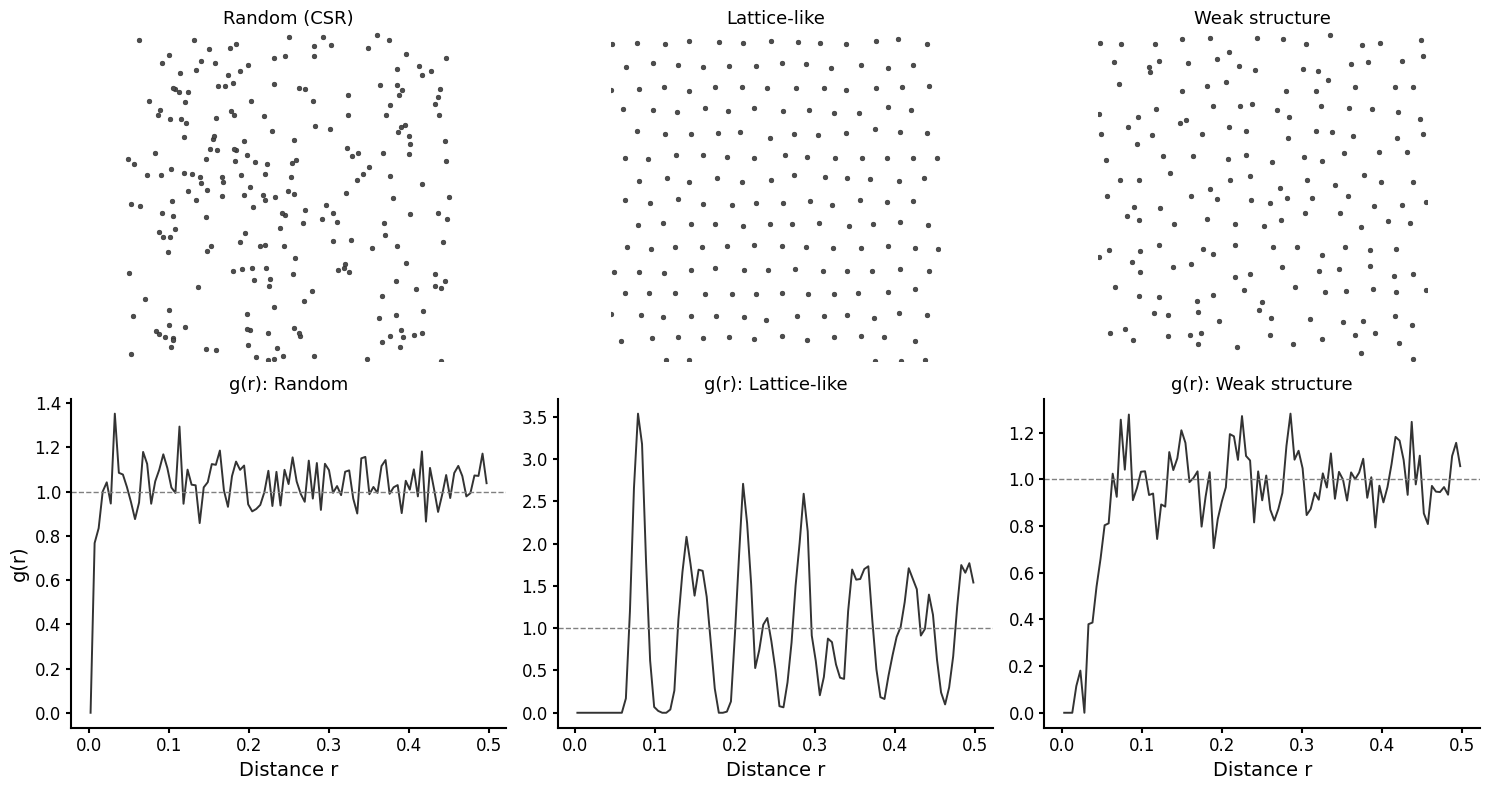

In [22]:
Lx = 1.
Ly = 1.

# --- Simulate patterns ---
poisson = simulate_poisson_rect(Lx, Ly, lam=200, seed=10)
lattice = simulate_hex_lattice(Lx, Ly, spacing=0.08, jitter=0.06, seed=2)

# Weak structure: shallow oscillations but many peak radii
weak = simulate_weak_structure_mixture(
    Lx, Ly, spacing=0.08, jitter=0.2, replace_frac=0.0, extra_lam=0.0, seed=3)

# --- PCF setup ---
r_max = 0.5
r_edges = np.linspace(0.0, r_max, 100)
r_edges[0] = 1e-6

r_p, g_p = pcf_translation_rect(poisson, Lx, Ly, r_edges)
r_l, g_l = pcf_translation_rect(lattice, Lx, Ly, r_edges)
r_w, g_w = pcf_translation_rect(weak,   Lx, Ly, r_edges)

# --- Plot: 2 rows x 3 cols ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ----------------------
# POINT PATTERNS (top row)
# ----------------------

axes[0,0].scatter(poisson[:,0], poisson[:,1],
                  s=12, color='0.3', edgecolor='0.1', linewidth=0.3)
axes[0,0].set_title("Random (CSR)", fontsize=13)

axes[0,1].scatter(lattice[:,0], lattice[:,1],
                  s=12, color='0.3', edgecolor='0.1', linewidth=0.3)
axes[0,1].set_title("Lattice-like", fontsize=13)

axes[0,2].scatter(weak[:,0], weak[:,1],
                  s=12, color='0.3', edgecolor='0.1', linewidth=0.3)
axes[0,2].set_title("Weak structure", fontsize=13)

# Remove EVERYTHING from spatial panels
for ax in axes[0]:
    ax.set_xlim(0, Lx)
    ax.set_ylim(0, Ly)
    ax.set_aspect("equal")
    ax.set_axis_off()     # <-- removes frame, ticks, spines completely

# ----------------------
# PCFs (bottom row)
# ----------------------
axes[1,0].plot(r_p, g_p, linewidth=1.4, color='0.2')
axes[1,0].axhline(1.0, linestyle='--', color='0.5', linewidth=1)
axes[1,0].set_title("g(r): Random", fontsize=13)

axes[1,1].plot(r_l, g_l, linewidth=1.4, color='0.2')
axes[1,1].axhline(1.0, linestyle='--', color='0.5', linewidth=1)
axes[1,1].set_title("g(r): Lattice-like", fontsize=13)

axes[1,2].plot(r_w, g_w, linewidth=1.4, color='0.2')
axes[1,2].axhline(1.0, linestyle='--', color='0.5', linewidth=1)
axes[1,2].set_title("g(r): Weak structure", fontsize=13)

for ax in axes[1]:
    ax.set_xlabel("Distance r", fontsize=14)
axes[1,0].set_ylabel("g(r)", fontsize=14)

# ----------------------
# Match plot_pcf.ipynb aesthetics
# ----------------------
for ax in axes.ravel():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

plt.tight_layout()
plt.show()